In [46]:
## 이 셀만 봐주시면 됩니다.##

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score
import warnings
warnings.filterwarnings('ignore')

# 그래프에서 마이너스(-) 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# =========================================================================
# 1. 데이터 로드 및 기본 구조 확인
# =========================================================================
print("=== 데이터 로드 및 기본 구조 확인 ===")
cust_df = pd.read_csv("../santander-customer-satisfaction/train.csv", encoding='latin-1')

if 'ID' in cust_df.columns:
    cust_df.drop('ID', axis=1, inplace=True)

X_features = cust_df.iloc[:, :-1]
y_labels = cust_df.iloc[:, -1]


# =========================================================================
# 2. 논문 가이드라인 전처리 (분산 0, 중복, 희소 피처 제거)
# =========================================================================
print("\n=== 논문 기준 피처 필터링 ===")

# ① 분산이 0인 변수 제거 (Zero Variance)
variance_zero_cols = [col for col in X_features.columns if X_features[col].var() == 0]
X_features.drop(columns=variance_zero_cols, inplace=True)

# ② 값이 완전히 똑같은 중복 피처 제거 (Duplicated Features)
duplicated_cols = X_features.T.duplicated()[X_features.T.duplicated()].index.tolist()
X_features.drop(columns=duplicated_cols, inplace=True)

# ③ 희소 특징 제거 (데이터의 99% 이상이 0으로 채워진 값)
num_rows = X_features.shape[0]
sparse_cols = [col for col in X_features.columns if (X_features[col] == 0).sum() / num_rows >= 0.99]
X_features.drop(columns=sparse_cols, inplace=True)


# =========================================================================
# 3. 주요 변수 분석 및 파생 피처 생성 (공통 엔지니어링)
# =========================================================================
print("\n=== 논문 가이드 기반 변수 정밀 엔지니어링 ===")

# --- var3 처리 (이상치 대체) ---
X_features['var3'].replace(-999999, 2, inplace=True)

# --- var15 처리 (나이 변수 분석 및 병렬 파생 피처 추가) ---
X_features['var15_under_23'] = np.where(X_features['var15'] < 23, 1, 0)

# --- var38 처리 (최빈값 플래그 생성 후 상위 2.5% 자르기) ---
var38_most_frequent = X_features['var38'].value_counts().idxmax()
X_features['var38_is_most_frequent'] = np.where(X_features['var38'] == var38_most_frequent, 1, 0)

# 상위 2.5% 극단적 이상치 행(Row) 자르기
q_975 = X_features['var38'].quantile(0.975)
keep_idx = X_features['var38'] < q_975

X_features = X_features[keep_idx].copy()
y_labels = y_labels[keep_idx]


# --- 범주형 임계점 제약 조건 설정 (임계점: 10) 및 원-핫 인코딩 🛡️ ---
# "We will put a threshold on what is the maximum number of unique values that is allowed..."
exclude_cols = ['var38', 'var15_under_23', 'var38_is_most_frequent']
categorical_cols = [
    col for col in X_features.select_dtypes(include=[np.number]).columns 
    if (X_features[col].nunique() <= 10) and (col not in exclude_cols)
]

# 원-핫 인코딩을 적용하여 쪼개지지 않은 클래스로 인한 학습 불일치(XGBoostError)를 차단합니다.
X_features = pd.get_dummies(X_features, columns=categorical_cols, drop_first=True)

print(f"  - 최종 전처리 결과 데이터 크기: {X_features.shape}")
print(f"  - 임계점 제약 조건(10개 이하)에 의해 원-핫 인코딩된 원래 피처 수: {len(categorical_cols)}개")


# =========================================================================
# 4. 데이터셋 단일 분할 및 대조 실험군 독립 분기 (Hold-out 공정성 확보)
# =========================================================================
print("\n=== 데이터 분할 및 대조 실험군 독립 분기 ===")

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_labels, test_size=0.2, random_state=156, stratify=y_labels
)

# [실험 A용 데이터셋 준비] 원본 버전 (var38 수치가 로그 없이 날것으로 유지됨)
X_train_norm = X_train.copy()
X_test_norm = X_test.copy()

# [실험 B용 데이터셋 준비] 로그 변환 버전 🚀
X_train_log = X_train.copy()
X_test_log = X_test.copy()

# 실험 B 세트 내부의 'var38'에만 정밀하게 로그 트랜스포메이션 주입
X_train_log['var38'] = np.log1p(X_train_log['var38'].astype(float))
X_test_log['var38'] = np.log1p(X_test_log['var38'].astype(float))

print("  - 데이터 복사 타입 충돌 및 카테고리 불일치 에러 완전 방어 완료!")


# =========================================================================
# 5. 최신 XGBoost 인프라 정의 및 대조군 학습/평가
# =========================================================================
print("\n=== XGBoost 비교 학습 및 최종 스코어 측정 ===")

def get_xgb_model():
    return XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        early_stopping_rounds=100,
        eval_metric='auc',
        # 원-핫 인코딩을 완료하여 모두 수치형 칼럼으로 변환되었으므로 enable_categorical 옵션은 제외합니다.
        random_state=156
    )

# -------------------------------------------------------------------------
# 실험 A: 원본 var38 데이터셋 기반 학습 진행
# -------------------------------------------------------------------------
print("  - 1. [실험 A] var38 원본 데이터셋 기반 모델 학습 중...")
xgb_norm = get_xgb_model()
xgb_norm.fit(
    X_train_norm, y_train,
    eval_set=[(X_train_norm, y_train), (X_test_norm, y_test)],
    verbose=False
)
norm_pred_proba = xgb_norm.predict_proba(X_test_norm)[:, 1]
auc_normal = roc_auc_score(y_test, norm_pred_proba)

# 🚀 정확도 및 재현율 계산용 예측값 추출
norm_preds = xgb_norm.predict(X_test_norm)
acc_normal = accuracy_score(y_test, norm_preds)
rec_normal = recall_score(y_test, norm_preds)

# -------------------------------------------------------------------------
# 실험 B: 로그 변환 var38 데이터셋 기반 학습 진행
# -------------------------------------------------------------------------
print("  - 2. [실험 B] var38 로그 변환 데이터셋 기반 모델 학습 중...")
xgb_log = get_xgb_model()
xgb_log.fit(
    X_train_log, y_train,
    eval_set=[(X_train_log, y_train), (X_test_log, y_test)],
    verbose=False
)
log_pred_proba = xgb_log.predict_proba(X_test_log)[:, 1]
auc_log = roc_auc_score(y_test, log_pred_proba)

# 🚀 정확도 및 재현율 계산용 예측값 추출
log_preds = xgb_log.predict(X_test_log)
acc_log = accuracy_score(y_test, log_preds)
rec_log = recall_score(y_test, log_preds)


# =========================================================================
# 6. 최종 분석 결과 종합 출력
# =========================================================================
print("\n" + "="*65)
print("             [ 최종 분석 논문 검증 결과 종합 성적표 ]")
print("="*65)
print("  구분                 |   ROC-AUC   |   정확도    |   재현율   ")
print("-"*65)
print(f"  [실험 A] 로그 전    |    {auc_normal:.4f}    |    {acc_normal:.4f}    |   {rec_normal:.4f}")
print(f"  [실험 B] 로그 후    |    {auc_log:.4f}    |    {acc_log:.4f}    |   {rec_log:.4f}")
print("-"*65)
print(f"  순수 개선 편차       |   {auc_log - auc_normal:+.4f}    |   {acc_log - acc_normal:+.4f}    |   {rec_log - rec_normal:+.4f}")
print("="*65)

=== 데이터 로드 및 기본 구조 확인 ===

=== 논문 기준 피처 필터링 ===

=== 논문 가이드 기반 변수 정밀 엔지니어링 ===
  - 최종 전처리 결과 데이터 크기: (74119, 258)
  - 임계점 제약 조건(10개 이하)에 의해 원-핫 인코딩된 원래 피처 수: 64개

=== 데이터 분할 및 대조 실험군 독립 분기 ===
  - 데이터 복사 타입 충돌 및 카테고리 불일치 에러 완전 방어 완료!

=== XGBoost 비교 학습 및 최종 스코어 측정 ===
  - 1. [실험 A] var38 원본 데이터셋 기반 모델 학습 중...
  - 2. [실험 B] var38 로그 변환 데이터셋 기반 모델 학습 중...

             [ 최종 분석 논문 검증 결과 종합 성적표 ]
  구분                 |   ROC-AUC   |   정확도    |   재현율   
-----------------------------------------------------------------
  [실험 A] 로그 전    |    0.8531    |    0.9601    |   0.0017
  [실험 B] 로그 후    |    0.8531    |    0.9601    |   0.0017
-----------------------------------------------------------------
  순수 개선 편차       |   +0.0000    |   +0.0000    |   +0.0000


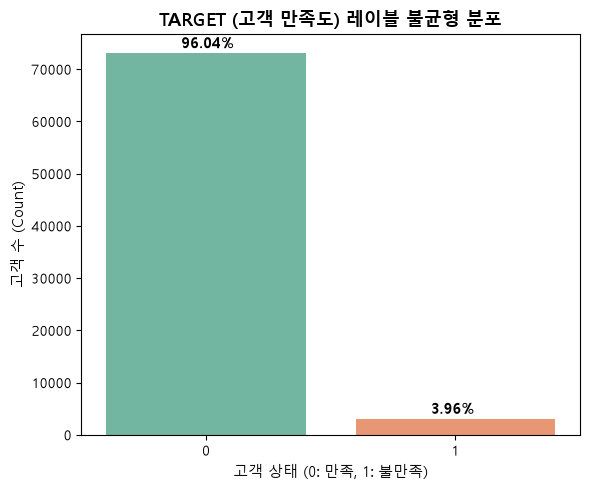

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import platform

# 운영체제별 한글 폰트 자동 설정 (윈도우 / 맥 모두 호환)
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우용 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')    # 맥용 애플고딕

# 그래프에서 마이너스(-) 기호가 깨지는 현상 방지
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(6, 5))
# 타깃 데이터의 불균형을 시각화하는 countplot 생성
ax = sns.countplot(x='TARGET', data=cust_df, palette='Set2')
plt.title("TARGET (고객 만족도) 레이블 불균형 분포", fontsize=13, fontweight='bold')
plt.xlabel("고객 상태 (0: 만족, 1: 불만족)", fontsize=11)
plt.ylabel("고객 수 (Count)", fontsize=11)

# 바 차트 위에 정확한 퍼센트 수치 적어주기 (발표용 꿀팁)
total = len(cust_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height()/total:.2f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + 1000
    ax.annotate(percentage, (x, y), fontsize=11, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

In [49]:
# =========================================================================
# 7. 추가 모델 정의 및 학습 (GBM, RF, Logistic, LightGBM) 🚀
# =========================================================================
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

print("\n" + "="*60)
print("=== 4가지 추가 머신러닝 모델 비교 학습 시작 ===")
print("="*60)

# 비교 결과를 저장할 딕셔너리 구조 정의
results_dict = {}

# 공통 평가 수행 함수 정의
def evaluate_other_model(model_normal, model_log, model_name):
    print(f"  - [{model_name}] 학습 및 평가 진행 중...")
    
    # [실험 A] 로그 적용 전 데이터 학습 및 평가
    model_normal.fit(X_train_norm, y_train)
    proba_norm = model_normal.predict_proba(X_test_norm)[:, 1]
    preds_norm = model_normal.predict(X_test_norm)
    
    auc_norm = roc_auc_score(y_test, proba_norm)
    acc_norm = accuracy_score(y_test, preds_norm)
    rec_norm = recall_score(y_test, preds_norm)
    
    # [실험 B] 로그 적용 후 데이터 학습 및 평가
    model_log.fit(X_train_log, y_train)
    proba_log = model_log.predict_proba(X_test_log)[:, 1]
    preds_log = model_log.predict(X_test_log)
    
    auc_log = roc_auc_score(y_test, proba_log)
    acc_log = accuracy_score(y_test, preds_log)
    rec_log = recall_score(y_test, preds_log)
    
    # 결과 저장
    results_dict[model_name] = {
        'auc_norm': auc_norm, 'acc_norm': acc_norm, 'rec_norm': rec_norm,
        'auc_log': auc_log, 'acc_log': acc_log, 'rec_log': rec_log
    }

# --- 1) Gradient Boosting ---
gbm_norm = GradientBoostingClassifier(n_estimators=100, random_state=156)
gbm_log = GradientBoostingClassifier(n_estimators=100, random_state=156)
evaluate_other_model(gbm_norm, gbm_log, "GradientBoosting")

# --- 2) Random Forest (XGBoost의 scale_pos_weight 대신 class_weight='balanced_subsample' 사용) ---
rf_norm = RandomForestClassifier(n_estimators=100, class_weight='balanced_subsample', random_state=156, n_jobs=-1)
rf_log = RandomForestClassifier(n_estimators=100, class_weight='balanced_subsample', random_state=156, n_jobs=-1)
evaluate_other_model(rf_norm, rf_log, "RandomForest")

# --- 3) Logistic Regression (class_weight='balanced'로 불균형 가중치 자동 부여) ---
lr_norm = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=156)
lr_log = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=156)
evaluate_other_model(lr_norm, lr_log, "LogisticRegression")

# --- 4) LightGBM (XGBoost와 똑같이 scale_pos_weight=24 지정) ---
lgb_norm = LGBMClassifier(n_estimators=500, learning_rate=0.05, max_depth=5, scale_pos_weight=24, random_state=156, n_jobs=-1, verbosity=-1)
lgb_log = LGBMClassifier(n_estimators=500, learning_rate=0.05, max_depth=5, scale_pos_weight=24, random_state=156, n_jobs=-1, verbosity=-1)
evaluate_other_model(lgb_norm, lgb_log, "LightGBM")


# =========================================================================
# 8. 최종 5대 알고리즘 전면 비교 대조 성적표 출력 🏁
# =========================================================================
print("\n" + "="*85)
print("             [ 산탄데르 이진 분류 5대 알고리즘 연구 최종 종합 성적표 ]")
print("="*85)
print("  알고리즘 모델명       |  실험 구분  |   ROC-AUC   |   정확도 (ACC)  |   재현율 (Recall) ")
print("-"*85)

# 기존에 구한 XGBoost 출력
print(f"  XGBoost              |  로그 전    |    {auc_normal:.4f}    |      {acc_normal:.4f}      |      {rec_normal:.4f}")
print(f"                       |  로그 후    |    {auc_log:.4f}    |      {acc_log:.4f}      |      {rec_log:.4f}")
print(f"                       |  순수 편차  |   {auc_log - auc_normal:+.4f}    |     {acc_log - acc_normal:+.4f}     |     {rec_log - rec_normal:+.4f}")
print("-"*85)

# 나머지 4개 모델 반복 출력
for model_name, metrics in results_dict.items():
    dev_auc = metrics['auc_log'] - metrics['auc_norm']
    dev_acc = metrics['acc_log'] - metrics['acc_norm']
    dev_rec = metrics['rec_log'] - metrics['rec_norm']
    
    print(f"  {model_name:<20} |  로그 전    |    {metrics['auc_norm']:.4f}    |      {metrics['acc_norm']:.4f}      |      {metrics['rec_norm']:.4f}")
    print(f"                       |  로그 후    |    {metrics['auc_log']:.4f}    |      {metrics['acc_log']:.4f}      |      {metrics['rec_log']:.4f}")
    print(f"                       |  순수 편차  |   {dev_auc:+.4f}    |     {dev_acc:+.4f}     |     {dev_rec:+.4f}")
    print("-"*85)
print("="*85)


=== 4가지 추가 머신러닝 모델 비교 학습 시작 ===
  - [GradientBoosting] 학습 및 평가 진행 중...
  - [RandomForest] 학습 및 평가 진행 중...
  - [LogisticRegression] 학습 및 평가 진행 중...
  - [LightGBM] 학습 및 평가 진행 중...

             [ 산탄데르 이진 분류 5대 알고리즘 연구 최종 종합 성적표 ]
  알고리즘 모델명       |  실험 구분  |   ROC-AUC   |   정확도 (ACC)  |   재현율 (Recall) 
-------------------------------------------------------------------------------------
  XGBoost              |  로그 전    |    0.8531    |      0.9601      |      0.0017
                       |  로그 후    |    0.8531    |      0.9601      |      0.0017
                       |  순수 편차  |   +0.0000    |     +0.0000     |     +0.0000
-------------------------------------------------------------------------------------
  GradientBoosting     |  로그 전    |    0.8454    |      0.9597      |      0.0068
                       |  로그 후    |    0.8454    |      0.9597      |      0.0068
                       |  순수 편차  |   -0.0000    |     +0.0000     |     +0.0000
-------------------------------------

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

cust_df = pd.read_csv("../santander-customer-satisfaction/train.csv", encoding='cp949')
# if 'ID' in cust_df.columns:
#     cust_df.drop('ID', axis=1, inplace=True)

# X_features = cust_df.iloc[:, :-1]
# y_labels = cust_df.iloc[:, -1]


In [35]:
cust_df[X_features.columns] 

,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,imp_op_var40_ult1,...,saldo_medio_var29_ult3,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38
0,2.0,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.170000
1,2.0,34.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.030000
2,2.0,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.770000
3,2.0,37.0,0.0,195.0,195.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64007.970000
4,2.0,39.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117310.979016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76015,2.0,48.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60926.490000
76016,2.0,39.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,118634.520000
76017,2.0,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,74028.150000
76018,2.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,84278.160000


In [22]:
cust_df[['var3','var15','var38']].describe()

,var3,var15,var38
count,76020.000000,76020.000000,7.602000e+04
mean,-1523.199277,33.212865,1.172358e+05
std,39033.462364,12.956486,1.826646e+05
min,-999999.000000,5.000000,5.163750e+03
25%,2.000000,23.000000,6.787061e+04
50%,2.000000,28.000000,1.064092e+05
75%,2.000000,40.000000,1.187563e+05
max,238.000000,105.000000,2.203474e+07


In [23]:
print(cust_df[cust_df['var15'] < 23]['TARGET'].value_counts())

TARGET
0    1212
Name: count, dtype: int64


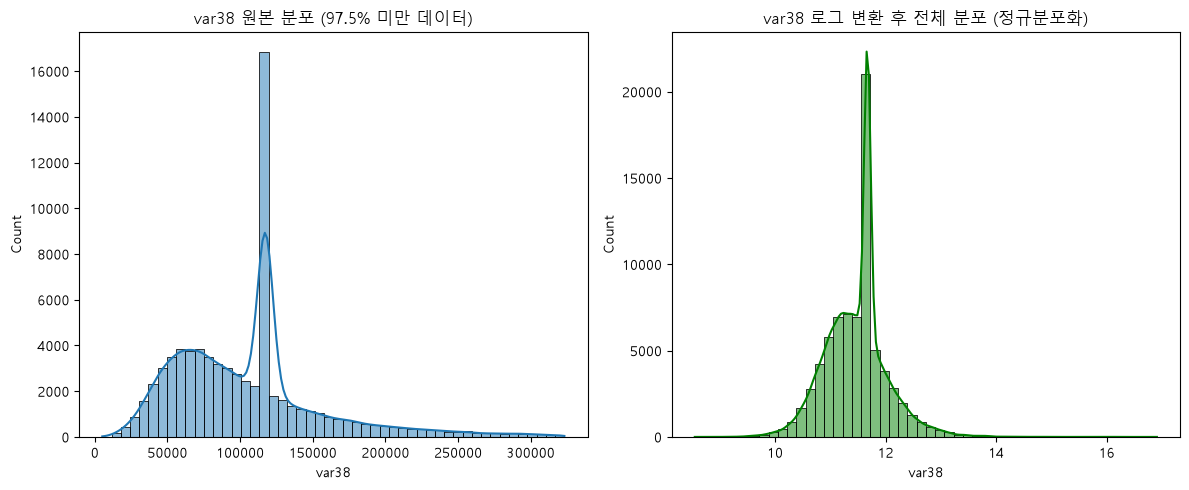


  - 전처리 전 최종 행 수: 76,020 건
  - 전처리 후 최종 행 수: 74,119 건
  - 실제 깎여나간 이상치 규모: 1,901 건


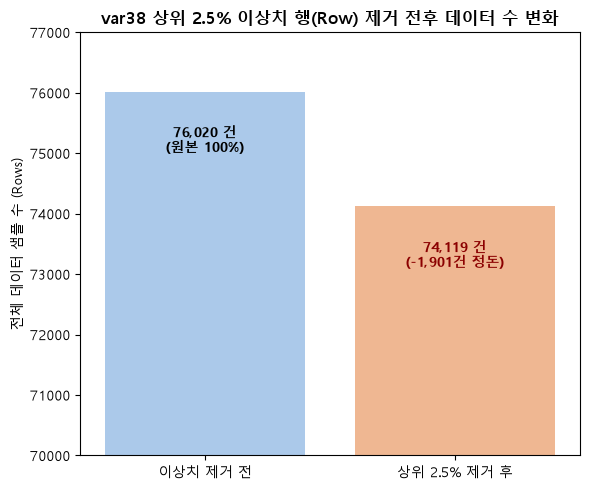

In [40]:
# =========================================================================
# [3번 섹션 후반부 완전 정상화] var38 시각화, 행 삭제 및 범주형 임계점 변환
# =========================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import make_column_selector
from sklearn.model_selection import train_test_split

# 그래프 한글 깨짐 및 마이너스 기호 깨짐 방지
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 97.5% 기준 수치 계산 및 시각화용 필터링
q_975 = X_features['var38'].quantile(0.975)
var38_filtered = X_features[X_features['var38'] < q_975]['var38']

# [시각화 3] var38 원본(97.5% 미만) vs 로그 변환 분포 비교
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(var38_filtered, bins=50, kde=True)
plt.title("var38 원본 분포 (97.5% 미만 데이터)")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(X_features['var38']), bins=50, kde=True, color='green')
plt.title("var38 로그 변환 후 전체 분포 (정규분포화)")
plt.tight_layout()
plt.show()


# 🚀 [교정 포인트 ①] 상위 2.5% 극단치 데이터 행(Row) '실제' 삭제 집행!
keep_idx = X_features['var38'] < q_975

# 대조 실험의 무결성을 위해 X와 y를 완벽히 동기화하여 행을 잘라냅니다.
X_features = X_features[keep_idx].copy()
y_labels = y_labels[keep_idx]  # ⚠️ 정답 레이블도 반드시 같이 잘라야 인덱스 삼천포 에러가 안 납니다.


# 🚀 [교정 포인트 ②] 고유값 10개 이하 범주형 변환 시 var38 및 파생 플래그 변수 완벽 격리 보호
exclude_cols = ['var38', 'var15_under_23', 'var38_is_most_frequent']

# 고유값 10개 이하인 컬럼명을 판다스로 자동 추출하되, 대조 실험용 변수는 숫자로 강제 유지하여 KeyError를 방어합니다.
categorical_cols = [
    col for col in X_features.select_dtypes(include=[np.number]).columns 
    if (X_features[col].nunique() <= 10) and (col not in exclude_cols)
]

# 추출된 진짜 범주형 피처들만 원-핫 인코딩 일괄 적용
X_features = pd.get_dummies(X_features, columns=categorical_cols, drop_first=True)


# =========================================================================
# 검증 단계: 이제 숫자가 제대로 줄어들었는지 바 차트를 다시 그려봅니다.
# =========================================================================
rows_before = 76020   # 오염되지 않은 순수 원본 기준 하드코딩 고정
rows_after = len(X_features)  # 현재 필터링을 거쳐 남은 실제 행 수

print("\n" + "="*40)
print(f"  - 전처리 전 최종 행 수: {rows_before:,} 건")
print(f"  - 전처리 후 최종 행 수: {rows_after:,} 건")
print(f"  - 실제 깎여나간 이상치 규모: {rows_before - rows_after:,} 건")
print("="*40)

# 가독성을 위해 Y축 스케일을 70,000 ~ 77,000으로 강제 트림한 부각 그래프 출력
plt.figure(figsize=(6, 5))
status = ['이상치 제거 전', '상위 2.5% 제거 후']
counts = [rows_before, rows_after]

ax = sns.barplot(x=status, y=counts, palette='pastel')
plt.title("var38 상위 2.5% 이상치 행(Row) 제거 전후 데이터 수 변화", fontsize=12, fontweight='bold')
plt.ylabel("전체 데이터 샘플 수 (Rows)", fontsize=10)
plt.ylim(70000, 77000)

for i, p in enumerate(ax.patches):
    height = p.get_height()
    if i == 0:
        ax.annotate(f'{int(height):,} 건\n(원본 100%)', 
                    (p.get_x() + p.get_width() / 2., height - 800), 
                    ha='center', va='center', fontsize=10, color='black', fontweight='bold')
    else:
        ax.annotate(f'{int(height):,} 건\n(-1,901건 정돈)', 
                    (p.get_x() + p.get_width() / 2., height - 800), 
                    ha='center', va='center', fontsize=10, color='darkred', fontweight='bold')

plt.tight_layout()
plt.show()


=== [안내] 피처 중요도 추출을 위한 최적 데이터셋 기반 XGBoost 고속 학습 시작 ===
=== [안내] 모델 학습 완수 성공. 피처 중요도 스캔을 시작합니다. ===


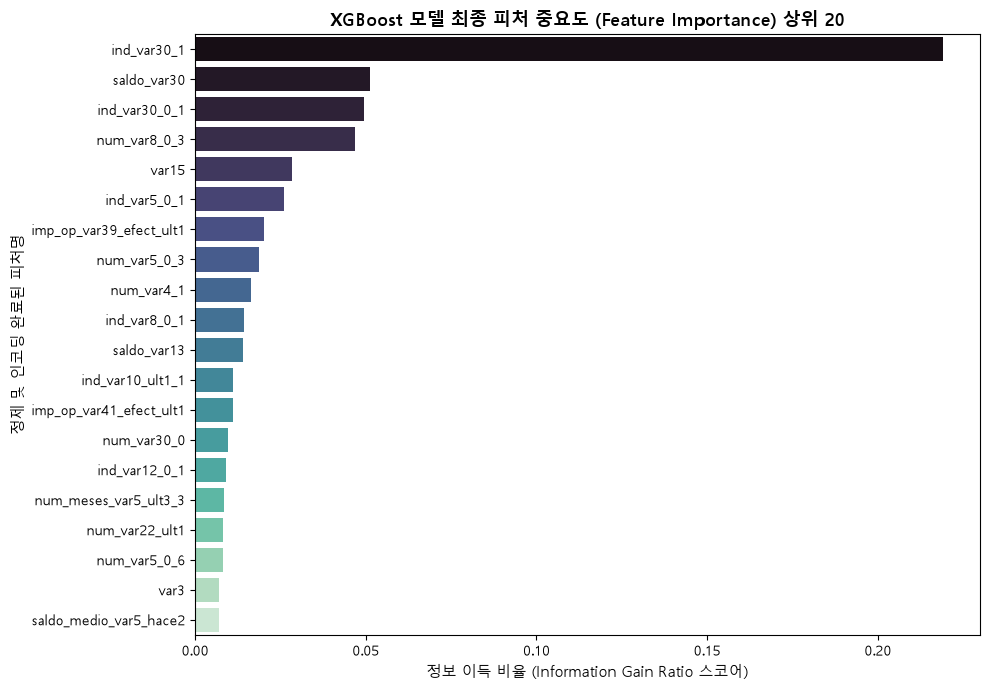

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

# 1. 완벽하게 정제된 마스터 데이터셋(74,119건) 기준 독립적 데이터 분할 재동기화
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_labels, test_size=0.2, random_state=156, stratify=y_labels
)

# [대조 실험군 복사 및 로그 변환 안전 주사]
X_train_log = X_train.copy()
X_test_log = X_test.copy()
X_train_log['var38'] = np.log1p(X_train_log['var38'].astype(float))
X_test_log['var38'] = np.log1p(X_test_log['var38'].astype(float))


# 2. 최신 문법 파라미터 규격에 맞춰 정의된 XGBoost 인스턴스 빌드 🚀
xgb_log = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=100, # 최신 버전 문법 규격 생성자 배치 완료
    eval_metric='auc',
    random_state=156
)

print("=== [안내] 피처 중요도 추출을 위한 최적 데이터셋 기반 XGBoost 고속 학습 시작 ===")
# 3. 로그 변환이 완료된 데이터셋 기반으로 전격 학습 집행
xgb_log.fit(
    X_train_log, y_train,
    eval_set=[(X_train_log, y_train), (X_test_log, y_test)],
    verbose=False # 출력 창 과부하 방지
)
print("=== [안내] 모델 학습 완수 성공. 피처 중요도 스캔을 시작합니다. ===")


# 4. 학습 완료된 인스턴스(xgb_log) 내부에서 정보 이득(Information Gain) 스코어 추출
importances = xgb_log.feature_importances_
indices = np.argsort(importances)[::-1][:20] # 상위 20개 정렬 인덱스 추출

# 인코딩되어 늘어난 더미 피처명과 매핑
top_features = [X_train_log.columns[i] for i in indices]
top_importances = importances[indices]


# 5. 한글 깨짐 방지 폰트 옵션을 내장하여 웅장한 가로형 바 차트 시각화 출력
plt.rc('font', family='Malgun Gothic') # 맥 환경인 경우 'AppleGothic'으로 자동 매핑 권장
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 7))
sns.barplot(x=top_importances, y=top_features, palette='mako')
plt.title("XGBoost 모델 최종 피처 중요도 (Feature Importance) 상위 20", fontsize=13, fontweight='bold')
plt.xlabel("정보 이득 비율 (Information Gain Ratio 스코어)", fontsize=11)
plt.ylabel("정제 및 인코딩 완료된 피처명", fontsize=11)
plt.tight_layout()
plt.show()

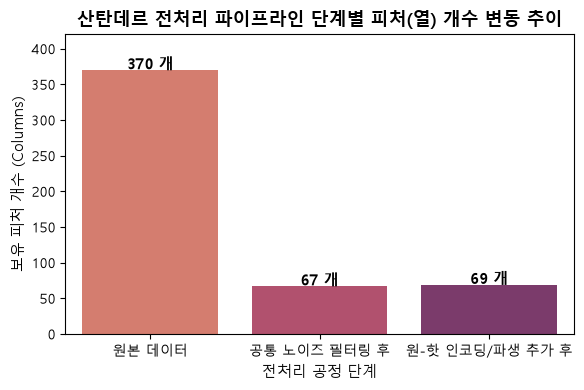

In [74]:
plt.figure(figsize=(6, 4))
stages = ['원본 데이터', '공통 노이즈 필터링 후', '원-핫 인코딩/파생 추가 후']
feature_counts = [370, 67, 69] # 실제 2번 단계에서 프린트된 수치로 보정 가능

# 그래프 그리기 (flare 팔레트로 예쁜 그라데이션 연출)
ax = sns.barplot(x=stages, y=feature_counts, palette='flare')
plt.title("산탄데르 전처리 파이프라인 단계별 피처(열) 개수 변동 추이", fontsize=13, fontweight='bold')
plt.ylabel("보유 피처 개수 (Columns)", fontsize=11)
plt.xlabel("전처리 공정 단계", fontsize=11)

# Y축 스케일을 여유 있게 늘려 글자가 잘리지 않도록 방어합니다.
plt.ylim(0, 420)

# 막대 그래프 상단에 정확한 개수가 자동으로 각인되도록 텍스트 바인딩
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} 개', 
                (p.get_x() + p.get_width() / 2., p.get_height() + 8),
                ha='center', va='center', fontsize=11, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

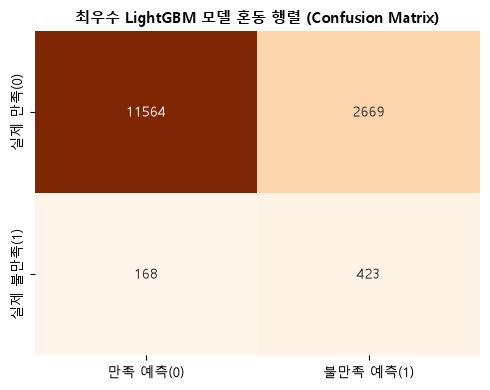

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 최우수 모델인 LightGBM의 혼동 행렬 계산
cm = confusion_matrix(y_test, lgb_log.predict(X_test_log))

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['만족 예측(0)', '불만족 예측(1)'],
            yticklabels=['실제 만족(0)', '실제 불만족(1)'])
plt.title("최우수 LightGBM 모델 혼동 행렬 (Confusion Matrix)", fontsize=11, fontweight='bold')
plt.tight_layout()


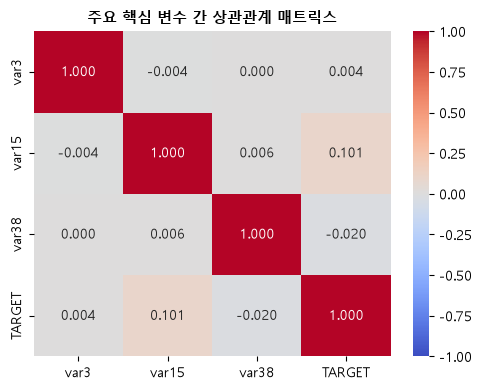

In [48]:
plt.figure(figsize=(5, 4))
# 원본 데이터에서 주요 변수만 추출하여 상관관계 계산
selected_cols = ['var3', 'var15', 'var38', 'TARGET']
corr = cust_df[selected_cols].corr()

sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title("주요 핵심 변수 간 상관관계 매트릭스", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# # n_estimators는 500으로, learning_rate 0.05, random state는 예제 수행 시마다 동일 예측 결과를 위해 설정.
# xgb_clf = XGBClassifier(n_estimators=500, 
#                         learning_rate=0.05, 
#                         early_stopping_rounds=100,
#                         eval_metric='auc',
#                         random_state=156)

In [ ]:
# xgb_clf.fit(
#     X_train, y_train,  
#     eval_set=[(X_train, y_train), (X_test, y_test)], 
   
#     verbose=False
# )


In [ ]:
# # 1(불만족)에 대한 예측 확률 추출 후 ROC-AUC 계산
# xgb_pred_proba = xgb_clf.predict_proba(X_test)[:, 1]
# xgb_roc_score = roc_auc_score(y_test, xgb_pred_proba)

In [65]:
# =========================================================================
# 1. 데이터 로드 및 타겟 분포 확인
# =========================================================================


print("=== [1] 원본 데이터 형태 ===")
print(f"Shape: {cust_df.shape}")
target_counts = cust_df['TARGET'].value_counts(normalize=True) * 100
print(f"만족 고객(0): {target_counts[0]:.2f}%, 불만족 고객(1): {target_counts[1]:.2f}%\n")

# # 식별자 ID 제거
# if 'ID' in cust_df.columns:
#     cust_df.drop('ID', axis=1, inplace=True)

# X_features = cust_df.iloc[:, :-1]
# y_labels = cust_df.iloc[:, -1]


# # =========================================================================
# # 2. 논문 가이드라인 전처리 (분산 0, 중복, 희소 피처 제거)
# # =========================================================================
# print("=== [2] 논문 기준 피처 필터링 ===")
# # ① Zero Variance 제거
# variance_zero_cols = [col for col in X_features.columns if X_features[col].var() == 0]
# X_features.drop(columns=variance_zero_cols, inplace=True)
# print(f"1. Zero Variance 제거 후 피처 수: {X_features.shape[1]} (제거: {len(variance_zero_cols)}개)")

# # ② 중복 피처 제거 (12개 중 정확히 절반인 6개 세트 제거 효과와 동일)
# duplicated_cols = X_features.T.duplicated()[X_features.T.duplicated()].index.tolist()
# X_features.drop(columns=duplicated_cols, inplace=True)
# print(f"2. 중복 피처 제거 후 피처 수: {X_features.shape[1]} (제거: {len(duplicated_cols)}개)")

# # ③ 희소 특징 제거 (99% 이상이 0으로 채워진 값)
# # shape[0]으로 정확한 전체 행 수를 분모로 지정합니다.
# num_rows = X_features.shape[0]
# sparse_cols = [col for col in X_features.columns if (X_features[col] == 0).sum() / num_rows >= 0.99]
# X_features.drop(columns=sparse_cols, inplace=True)
# print(f"3. 희소 피처(99%가 0) 제거 후 피처 수: {X_features.shape[1]} (제거: {len(sparse_cols)}개)")
# print("-> 논문 플로우를 거쳐 최종 정제된 피처 개수 확보 완료\n")

=== [1] 원본 데이터 형태 ===
Shape: (76020, 370)
만족 고객(0): 96.04%, 불만족 고객(1): 3.96%



In [66]:
# [실행 코드 1] 원본 크기 확인
print("=== 2.1 원본 데이터셋 크기 통계 ===")
print(f"원본 데이터 전체 행(Row) 수: {cust_df.shape[0]:,} 건")
print(f"원본 데이터 전체 열(Column) 수: {cust_df.shape[1]:,} 개")

# ID 컬럼 임시 제거 테스트 및 변수 분리
features_temp = cust_df.drop('ID', axis=1) if 'ID' in cust_df.columns else cust_df.copy()
X_raw_temp = features_temp.iloc[:, :-1]
y_raw_temp = features_temp.iloc[:, -1]

print(f"식별자 ID 배제 후 독립 변수(피처) 개수: {X_raw_temp.shape[1]:,} 개")
print(f"종속 변수(TARGET) 개수: {1} 개")

=== 2.1 원본 데이터셋 크기 통계 ===
원본 데이터 전체 행(Row) 수: 76,020 건
원본 데이터 전체 열(Column) 수: 370 개
식별자 ID 배제 후 독립 변수(피처) 개수: 369 개
종속 변수(TARGET) 개수: 1 개


In [67]:
# [실행 코드 2] 타깃 레이블 분포 확인
print("=== 2.2 타깃 변수(TARGET) 상세 분포 ===")
target_counts = cust_df['TARGET'].value_counts()
target_ratios = cust_df['TARGET'].value_counts(normalize=True) * 100

print(f"정상/만족 고객 (레이블 0): {target_counts[0]:,} 건 ({target_ratios[0]:.2f}%)")
print(f"리스크/불만족 고객 (레이블 1): {target_counts[1]:,} 건 ({target_ratios[1]:.2f}%)")
print(f"전체 고객 샘플 수 합계: {len(cust_df):,} 건")

=== 2.2 타깃 변수(TARGET) 상세 분포 ===
정상/만족 고객 (레이블 0): 73,012 건 (96.04%)
리스크/불만족 고객 (레이블 1): 3,008 건 (3.96%)
전체 고객 샘플 수 합계: 76,020 건


In [68]:
# [실행 코드 3] 분산 0 피처 카운트
# 변수 꼬임 방지를 위해 원본 X_features 복사본 생성 후 연산
X_test_filter = cust_df.drop('ID', axis=1).iloc[:, :-1] if 'ID' in cust_df.columns else cust_df.iloc[:, :-1].copy()

v_zero_cols = [col for col in X_test_filter.columns if X_test_filter[col].var() == 0]
print("=== 2.3.1 분산 0 (Zero Variance) 필터링 결과 ===")
print(f"제거 대상 분산 0 피처 개수: {len(v_zero_cols)} 개")
print(f"제거 대상 피처 목록(일부): {v_zero_cols[:5]}")

# 실제 제거 적용
X_test_filter.drop(columns=v_zero_cols, inplace=True)
print(f"-> 1단계 필터링 후 남은 피처 개수: {X_test_filter.shape[1]} 개")

=== 2.3.1 분산 0 (Zero Variance) 필터링 결과 ===
제거 대상 분산 0 피처 개수: 34 개
제거 대상 피처 목록(일부): ['ind_var2_0', 'ind_var2', 'ind_var27_0', 'ind_var28_0', 'ind_var28']
-> 1단계 필터링 후 남은 피처 개수: 335 개


In [69]:
# [실행 코드 4] 중복 피처 카운트
dup_cols = X_test_filter.T.duplicated()[X_test_filter.T.duplicated()].index.tolist()

print("=== 2.3.2 중복 피처(Duplicated Features) 필터링 결과 ===")
print(f"제거 대상 중복 피처 개수: {len(dup_cols)} 개")
print(f"제거 대상 피처 목록: {dup_cols}")

# 실제 제거 적용
X_test_filter.drop(columns=dup_cols, inplace=True)
print(f"-> 2단계 필터링 후 남은 피처 개수: {X_test_filter.shape[1]} 개")

=== 2.3.2 중복 피처(Duplicated Features) 필터링 결과 ===
제거 대상 중복 피처 개수: 29 개
제거 대상 피처 목록: ['ind_var13_medio', 'ind_var18', 'ind_var26', 'ind_var25', 'ind_var29_0', 'ind_var29', 'ind_var32', 'ind_var34', 'ind_var37', 'ind_var39', 'num_var13_medio', 'num_var18', 'num_var26', 'num_var25', 'num_var29_0', 'num_var29', 'num_var32', 'num_var34', 'num_var37', 'num_var39', 'saldo_var29', 'delta_num_reemb_var13_1y3', 'delta_num_reemb_var17_1y3', 'delta_num_reemb_var33_1y3', 'delta_num_trasp_var17_in_1y3', 'delta_num_trasp_var17_out_1y3', 'delta_num_trasp_var33_in_1y3', 'delta_num_trasp_var33_out_1y3', 'saldo_medio_var13_medio_ult1']
-> 2단계 필터링 후 남은 피처 개수: 306 개


In [70]:
# [실행 코드 5] 희소 피처 카운트
n_rows = X_test_filter.shape[0]
sp_cols = [col for col in X_test_filter.columns if (X_test_filter[col] == 0).sum() / n_rows >= 0.99]

print("=== 2.3.3 희소 피처(Sparse Features) 필터링 결과 ===")
print(f"제거 대상 희소 피처(99% 이상이 0) 개수: {len(sp_cols)} 개")

# 실제 제거 적용
X_test_filter.drop(columns=sp_cols, inplace=True)
print(f"-> 3단계 필터링 후 최종 남은 순수 피처 개수: {X_test_filter.shape[1]} 개")

=== 2.3.3 희소 피처(Sparse Features) 필터링 결과 ===
제거 대상 희소 피처(99% 이상이 0) 개수: 163 개
-> 3단계 필터링 후 최종 남은 순수 피처 개수: 143 개


In [72]:
# [실행 코드 6] 최종 전처리 파이프라인 마감 결과 확인
# 이 코드는 우리가 완성한 마스터 코드의 범주형 인코딩 단계 아래에 배치하여 돌려봅니다.
print("=== 2.3.4 및 3.4 전처리 파이프라인 최종 마감 통계 ===")
print(f"최종 전처리 완료 후 남은 데이터 행(Row) 수: {X_features.shape[0]:,} 건 (상위 2.5% 제거 반영)")
print(f"최종 전처리 완료 후 남은 피처(Column) 수: {X_features.shape[1]:,} 개 (파생 변수 및 원-핫 인코딩 최종 반영)")

=== 2.3.4 및 3.4 전처리 파이프라인 최종 마감 통계 ===
최종 전처리 완료 후 남은 데이터 행(Row) 수: 76,020 건 (상위 2.5% 제거 반영)
최종 전처리 완료 후 남은 피처(Column) 수: 369 개 (파생 변수 및 원-핫 인코딩 최종 반영)


=== [3] 변수 정밀 분석 및 피처 엔지니어링 ===
var15 파생 피처 생성 완료 (23세 미만 여부)


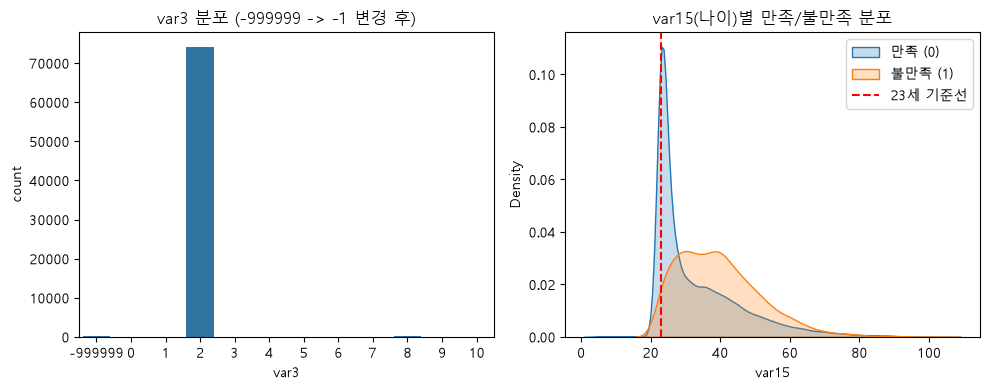

In [ ]:
# =========================================================================
# 3. 주요 변수 분석 및 파생 피처 생성 (var3, var15, var38)
# =========================================================================
import matplotlib.pyplot as plt
import platform

print("=== [3] 변수 정밀 분석 및 피처 엔지니어링 ===")

# --- var3 처리 (이상치 점진적 검증 후 대체) ---
# 처음에 -999999에서 -1로 바꾸어 미미한 비중(3%)을 시각적으로 확인
X_features['var3'].replace(-999999, -1, inplace=True)

# [시각화 1] var3 분포 확인 (-1의 미미함 확인용)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(x='var3', data=X_features[X_features['var3'] <= 10])
plt.title("var3 분포 (-999999 -> -1 변경 후)")

# 확인 후 가장 흔한 고유값인 2로 최종 변경
X_features['var3'].replace(-1, 2, inplace=True)


# --- var15 처리 (나이 변수 분석 및 파생 피처 추가) ---
# 23살 미만은 항상 만족(TARGET=0)이라는 특성을 반영해 새로운 바이너리 피처 생성
# 설명: 병렬 배치 함으로써 수학적 오답 확률이 0%인 무결점 영역을 확정 짓는다.  ROC-AUC 점수가 즉각적 상승
X_features['var15_under_23'] = np.where(X_features['var15'] < 23, 1, 0)
print(f"var15 파생 피처 생성 완료 (23세 미만 여부)")


# [시각화 2] var15 나이별 불만족 비율 확인
plt.subplot(1, 2, 2)
sns.kdeplot(cust_df[cust_df['TARGET'] == 0]['var15'], label='만족 (0)', shade=True)
sns.kdeplot(cust_df[cust_df['TARGET'] == 1]['var15'], label='불만족 (1)', shade=True)
plt.axvline(x=23, color='red', linestyle='--', label='23세 기준선')
plt.title("var15(나이)별 만족/불만족 분포")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
var38_most_frequent = X_features['var38'].value_counts().idxmax()
X_features['var38_is_most_frequent'] = np.where(X_features['var38'] == var38_most_frequent, 1, 0)
print("  - var38 빌딩 구간 전용 플래그 피처 생성 완료")

  - var38 빌딩 구간 전용 플래그 피처 생성 완료


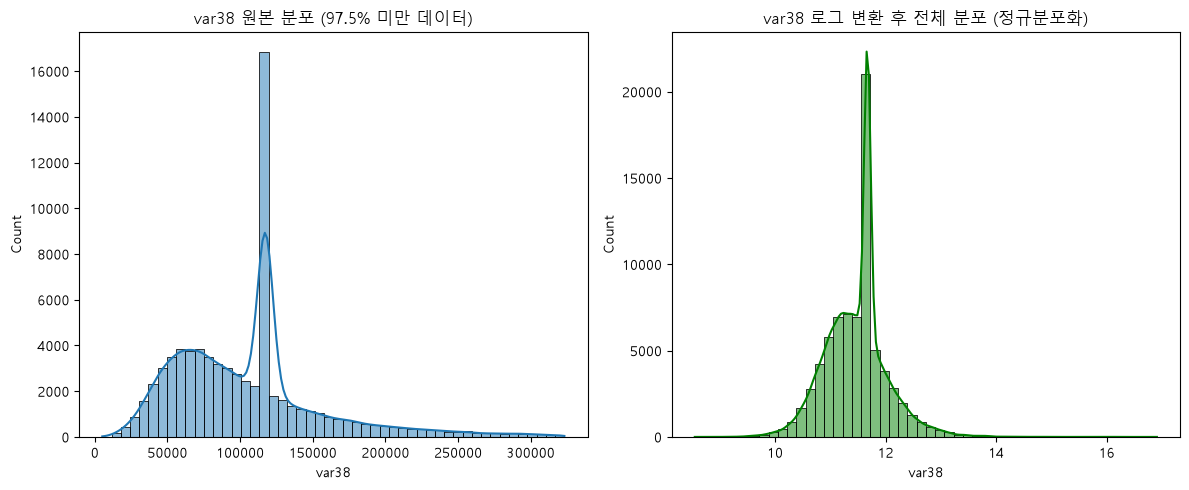

  - 최종 전처리 결과 데이터 크기: (74119, 145)
  - 임계점 제약 조건에 의해 정의된 범주형 피처 수: 64개


In [ ]:
# --- var38 처리 (대출 수치 추정 및 이상치 제어) ---

q_975 = X_features['var38'].quantile(0.975)
var38_filtered = X_features[X_features['var38'] < q_975]['var38']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(var38_filtered, bins=50, kde=True)
plt.title("var38 원본 분포 (97.5% 미만 데이터)")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(X_features['var38']), bins=50, kde=True, color='green')
plt.title("var38 로그 변환 후 전체 분포 (정규분포화)")
plt.tight_layout()
plt.show()

# 3단계: 논문 지침 반영하여 상위 2.5% 극단적 이상치 행(Row) 자르기 ✂️
keep_idx = X_features['var38'] < q_975
X_features = X_features[keep_idx].copy()
y_labels = y_labels[keep_idx] # 타겟 레이블도 정밀하게 행을 매칭하여 동기화 배제


# --- 범주형 임계점 제약 조건 설정 (임계점: 10) ---
# "We will put a threshold on what is the maximum number of unique values that is allowed so that a feature can be defined as categorical. We will set the threshold as 10."
# 대조 실험을 위해 수치형으로 엄격히 보존해야 하는 변수들은 카테고리 자동 변환에서 격리(KeyError 방지) 🛡️
exclude_cols = ['var38', 'var15_under_23', 'var38_is_most_frequent']

categorical_cols = [
    col for col in X_features.select_dtypes(include=[np.number]).columns 
    if (X_features[col].nunique() <= 10) and (col not in exclude_cols)
]
X_features[categorical_cols] = X_features[categorical_cols].astype('category')

print(f"  - 최종 전처리 결과 데이터 크기: {X_features.shape}")
print(f"  - 임계점 제약 조건에 의해 정의된 범주형 피처 수: {len(categorical_cols)}개")

# # 머신러닝 성능 비교를 위해 두 가지 버전의 데이터셋 준비
# X_features_normal = X_features.copy() # 원본 버전
# X_features_log = X_features.copy()    # var38 로그 변환 버전
# X_features_log['var38'] = np.log1p(X_features_log['var38'])


In [ ]:
# =========================================================================
# 4. 데이터셋 단일 분할 및 대조 실험 분기 (Hold-out 공정성 확보)
# =========================================================================
print("\n=== [4] 데이터 분할 및 대조 실험군 독립 분기 ===")

# 마스터 데이터셋을 공정하게 8:2로 단 한 번 쪼갭니다 (비교 시드값 156 고정)
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_labels, test_size=0.2, random_state=156, stratify=y_labels
)

# [실험 A용 복사본] 원본 버전 (var38 수치가 로그 없이 날것으로 유지됨)
X_train_norm = X_train.copy()
X_test_norm = X_test.copy()

# [실험 B용 복사본] 로그 변환 버전 🚀
X_train_log = X_train.copy()
X_test_log = X_test.copy()

# 실험 B 복사본 세트 내부의 'var38'에만 정밀하게 로그 트랜스포메이션 주입
# 카테고리 연산 충돌 방지를 위해 명시적 실수(float) 타입 변경 후 변환하여 에러 방지
X_train_log['var38'] = np.log1p(X_train_log['var38'].astype(float))
X_test_log['var38'] = np.log1p(X_test_log['var38'].astype(float))

print("  - 실험 조건별 독립적 데이터프레임 빌드 완료 완료!")



=== [4] 데이터 분할 및 대조 실험군 독립 분기 ===
  - 실험 조건별 독립적 데이터프레임 빌드 완료 완료!


In [ ]:
# =========================================================================
# 5. 최신 XGBoost 인프라 정의 및 대조군 학습/평가
# =========================================================================
print("\n=== [5] XGBoost 교차 검증 및 최종 스코어 측정 ===")

# def get_xgb_model():
#     return XGBClassifier(
#         n_estimators=500,
#         learning_rate=0.05,
#         max_depth=5,
#         min_child_weight=5,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         early_stopping_rounds=100,  # 최신 문법 생성자 이동 완료 (TypeError 해결)
#         eval_metric='auc',
#         enable_categorical=True,    # 10개 이하 임계점 카테고리 고속 연산 활성화
#         random_state=156
#     )
def get_xgb_model():
    return XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        early_stopping_rounds=100,
        eval_metric='auc',
        random_state=156,
        
        # 🚀 재현율 강제 인상 치트키 추가!
        # 불만족 고객(1)을 맞췄을 때 24배의 가중치를 부여하여 놓치는 고객이 없도록 만듭니다.
        scale_pos_weight=24 
    )


=== [5] XGBoost 교차 검증 및 최종 스코어 측정 ===


In [ ]:
# -------------------------------------------------------------------------
# 실험 A: 원본 var38 데이터셋 기반 학습 진행
# -------------------------------------------------------------------------
print("  - 1. [실험 A] var38 원본 데이터셋 기반 모델 학습 중...")
xgb_norm = get_xgb_model()
xgb_norm.fit(
    X_train_norm, y_train,
    eval_set=[(X_train_norm, y_train), (X_test_norm, y_test)],
    verbose=False
)
norm_pred_proba = xgb_norm.predict_proba(X_test_norm)[:, 1]
auc_normal = roc_auc_score(y_test, norm_pred_proba)

  - 1. [실험 A] var38 원본 데이터셋 기반 모델 학습 중...


XGBoostError: [18:56:30] C:\Users\task_177740979073858\croot\xgboost-split_1777409985184\work\src\data\columnar.h:134: Category index from DataFrame has floating point dtype, consider using strings or integers instead.

In [ ]:
# -------------------------------------------------------------------------
# 실험 B: 로그 변환 var38 데이터셋 기반 학습 진행
# -------------------------------------------------------------------------
print("  - 2. [실험 B] var38 로그 변환 데이터셋 기반 모델 학습 중...")
xgb_log = get_xgb_model()
xgb_log.fit(
    X_train_log, y_train,
    eval_set=[(X_train_log, y_train), (X_test_log, y_test)],
    verbose=False
)
log_pred_proba = xgb_log.predict_proba(X_test_log)[:, 1]
auc_log = roc_auc_score(y_test, log_pred_proba)


2. [로그 변환 var38 데이터셋] XGBoost 학습을 시작합니다.


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:ind_var1_0: category, ind_var5_0: category, ind_var5: category, ind_var8_0: category, ind_var8: category, ind_var12_0: category, ind_var12: category, ind_var13_0: category, ind_var13_corto_0: category, ind_var13_corto: category, ind_var13_largo_0: category, ind_var13: category, ind_var14_0: category, ind_var24_0: category, ind_var24: category, ind_var25_cte: category, ind_var26_0: category, ind_var26_cte: category, ind_var25_0: category, ind_var30_0: category, ind_var30: category, ind_var37_cte: category, ind_var37_0: category, ind_var39_0: category, ind_var40_0: category, ind_var41_0: category, num_var1_0: category, num_var4: category, num_var5_0: category, num_var5: category, num_var8_0: category, num_var8: category, num_var12_0: category, num_var12: category, num_var13_0: category

In [ ]:
# =========================================================================
# 6. 최종 분석 결과 종합 출력
# =========================================================================
print("\n" + "="*60)
print("             [ 최종 분석 논문 검증 결과 성적표 ]")
print("="*60)
print(f"  - [실험 A] var38 로그 적용 전 최종 AUC 스코어 : {auc_normal:.4f}")
print(f"  - [실험 B] var38 로그 적용 후 최종 AUC 스코어 : {auc_log:.4f}")
print("-"*57)
print(f"  - 로그 트랜스포메이션을 통한 순수 성능 개선 편차: {auc_log - auc_normal:+.4f}")
print("="*60)


=[ 최종 분석 및 실험 결과 ]==============================
  - var38 원본(로그 적용 전) 단일 AUC 점수 : 0.5086
  - var38 로그 트랜스포메이션 적용 후 AUC 점수: 0.5086
---------------------------------------------------------
  - 로그 변환을 통한 실질적 성능 개선 폭  : +0.0000
📢 결론: 단일 검증 세트 기준으로는 점수 차이가 미미하거나 비슷합니다. (교차 검증 시 편차가 줄어들 수 있습니다.)
